In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
un_df = pd.read_csv("dataset_datascience.csv", encoding = 'ISO-8859-1')

C:\Users\Masini\AppData\Local\Temp\ipykernel_6284\3885380738.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  un_df = pd.read_csv("dataset_datascience.csv", encoding = 'ISO-8859-1')


In [3]:
un_df.head()

,REF_AREA,Geographic area,Regional group,Indicator,Sex,Wealth Quintile,Series Name,Series Year,Reference Date,Observation Value,...,Country notes,Observation Status,Unit of measure,Series Type,Series Category,Series Method,Age Group of Women,Time Since First Birth,Definition,Interval
0,AFG,Afghanistan,NaN,Neonatal mortality rate,Total,Total,Afghanistan Health Survey 2018 (Direct),2018,1995.5,47.869030,...,NaN,Excluded from IGME,"Deaths per 1,000 live births",Direct,Others,Survey/Census with Full Birth Histories,NaN,NaN,NaN,5.0
1,AFG,Afghanistan,NaN,Neonatal mortality rate,Total,Total,Afghanistan Health Survey 2018 (Direct),2018,2000.5,35.349317,...,NaN,Excluded from IGME,"Deaths per 1,000 live births",Direct,Others,Survey/Census with Full Birth Histories,NaN,NaN,NaN,5.0
2,AFG,Afghanistan,NaN,Neonatal mortality rate,Total,Total,Afghanistan Health Survey 2018 (Direct),2018,2005.5,27.699219,...,NaN,Excluded from IGME,"Deaths per 1,000 live births",Direct,Others,Survey/Census with Full Birth Histories,NaN,NaN,NaN,5.0
3,AFG,Afghanistan,NaN,Neonatal mortality rate,Total,Total,Afghanistan Health Survey 2018 (Direct),2018,2010.5,21.056003,...,NaN,Excluded from IGME,"Deaths per 1,000 live births",Direct,Others,Survey/Census with Full Birth Histories,NaN,NaN,NaN,5.0
4,AFG,Afghanistan,NaN,Neonatal mortality rate,Total,Total,Afghanistan Health Survey 2018 (Direct),2018,2015.5,20.167379,...,NaN,Excluded from IGME,"Deaths per 1,000 live births",Direct,Others,Survey/Census with Full Birth Histories,NaN,NaN,NaN,5.0


In [4]:
eac_country_codes = ["BDI", "COD", "KEN", "RWA","SSD", "SOM", "TZA", "UGA"]

un_df['REF_AREA'] = un_df['REF_AREA'].str.strip().str.upper()
un_df['Series Name'] = un_df['Series Name'].str.strip().str.lower()
un_df = un_df[(un_df['REF_AREA'].isin(eac_country_codes)) & (un_df['Series Name'] == "un igme estimate")]
un_df

,REF_AREA,Geographic area,Regional group,Indicator,Sex,Wealth Quintile,Series Name,Series Year,Reference Date,Observation Value,...,Country notes,Observation Status,Unit of measure,Series Type,Series Category,Series Method,Age Group of Women,Time Since First Birth,Definition,Interval
6402,BDI,Burundi,NaN,Neonatal mortality rate,Total,Total,un igme estimate,2023,1964.5,49.749877,...,NaN,Normal value,"Deaths per 1,000 live births",NaN,NaN,NaN,NaN,NaN,NaN,1.0
6403,BDI,Burundi,NaN,Neonatal mortality rate,Total,Total,un igme estimate,2023,1965.5,49.900299,...,NaN,Normal value,"Deaths per 1,000 live births",NaN,NaN,NaN,NaN,NaN,NaN,1.0
6404,BDI,Burundi,NaN,Neonatal mortality rate,Total,Total,un igme estimate,2023,1966.5,49.952441,...,NaN,Normal value,"Deaths per 1,000 live births",NaN,NaN,NaN,NaN,NaN,NaN,1.0
6405,BDI,Burundi,NaN,Neonatal mortality rate,Total,Total,un igme estimate,2023,1967.5,49.872070,...,NaN,Normal value,"Deaths per 1,000 live births",NaN,NaN,NaN,NaN,NaN,NaN,1.0
6406,BDI,Burundi,NaN,Neonatal mortality rate,Total,Total,un igme estimate,2023,1968.5,49.937962,...,NaN,Normal value,"Deaths per 1,000 live births",NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113635,UGA,Uganda,NaN,Under-five mortality rate,Total,Total,un igme estimate,2023,2019.5,45.307572,...,NaN,Normal value,"Deaths per 1,000 live births",NaN,NaN,NaN,NaN,NaN,NaN,1.0
113636,UGA,Uganda,NaN,Under-five mortality rate,Total,Total,un igme estimate,2023,2020.5,43.509117,...,NaN,Normal value,"Deaths per 1,000 live births",NaN,NaN,NaN,NaN,NaN,NaN,1.0
113637,UGA,Uganda,NaN,Under-five mortality rate,Total,Total,un igme estimate,2023,2021.5,41.786456,...,NaN,Normal value,"Deaths per 1,000 live births",NaN,NaN,NaN,NaN,NaN,NaN,1.0
113638,UGA,Uganda,NaN,Under-five mortality rate,Total,Total,un igme estimate,2023,2022.5,40.493282,...,NaN,Normal value,"Deaths per 1,000 live births",NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [5]:
import geopandas as gpd
import os

gdf_list = []

for code in eac_country_codes:
    filepath = f'shapefiles/{code}/gadm41_{code}_0.shp'
    if os.path.exists(filepath):
        gdf = gpd.read_file(filepath)
        gdf['ISO_A3'] = code  
        gdf_list.append(gdf)

gdf_eac = pd.concat(gdf_list, ignore_index=True)

In [6]:
gdf_eac

,GID_0,COUNTRY,geometry,ISO_A3
0,BDI,Burundi,"POLYGON ((30.04515 -4.25684, 30.04523 -4.2576,...",BDI
1,COD,Democratic Republic of the Congo,"MULTIPOLYGON (((27.24913 -11.79462, 27.2478 -1...",COD
2,KEN,Kenya,"MULTIPOLYGON (((39.38014 -4.71792, 39.37986 -4...",KEN
3,RWA,Rwanda,"POLYGON ((29.71332 -2.81759, 29.71295 -2.81774...",RWA
4,SSD,South Sudan,"POLYGON ((29.79568 4.3843, 29.79645 4.38899, 2...",SSD
5,SOM,Somalia,"MULTIPOLYGON (((41.61347 -1.6093, 41.61319 -1....",SOM
6,TZA,Tanzania,"MULTIPOLYGON (((39.35587 -11.09155, 39.34812 -...",TZA
7,UGA,Uganda,"POLYGON ((29.91125 -1.47687, 29.91099 -1.47613...",UGA


In [11]:
un_df['Reference Date'] = un_df['Reference Date'].astype(int)

filtered = un_df[un_df['Indicator'].isin(['Neonatal mortality rate', 'Under-five mortality rate'])]

filtered_latest = filtered.sort_values('Reference Date').groupby(['REF_AREA', 'Indicator'], as_index=False).last()

un_df_pivot = filtered_latest.pivot(index='REF_AREA', columns='Indicator', values='Observation Value').reset_index()
un_df_pivot

Indicator,REF_AREA,Neonatal mortality rate,Under-five mortality rate
0,BDI,19.603026,45.025732
1,COD,25.346972,73.189681
2,KEN,21.513320,35.601468
3,RWA,18.126902,36.115174
4,SOM,34.904816,109.539187
5,SSD,40.240552,94.464741
6,TZA,20.564352,42.014984
7,UGA,17.851216,38.807676


In [12]:
gdf_merged = gdf_eac.merge(un_df_pivot, left_on='ISO_A3', right_on='REF_AREA')

In [13]:
gdf_merged

,GID_0,COUNTRY,geometry,ISO_A3,REF_AREA,Neonatal mortality rate,Under-five mortality rate
0,BDI,Burundi,"POLYGON ((30.04515 -4.25684, 30.04523 -4.2576,...",BDI,BDI,19.603026,45.025732
1,COD,Democratic Republic of the Congo,"MULTIPOLYGON (((27.24913 -11.79462, 27.2478 -1...",COD,COD,25.346972,73.189681
2,KEN,Kenya,"MULTIPOLYGON (((39.38014 -4.71792, 39.37986 -4...",KEN,KEN,21.513320,35.601468
3,RWA,Rwanda,"POLYGON ((29.71332 -2.81759, 29.71295 -2.81774...",RWA,RWA,18.126902,36.115174
4,SSD,South Sudan,"POLYGON ((29.79568 4.3843, 29.79645 4.38899, 2...",SSD,SSD,40.240552,94.464741
5,SOM,Somalia,"MULTIPOLYGON (((41.61347 -1.6093, 41.61319 -1....",SOM,SOM,34.904816,109.539187
6,TZA,Tanzania,"MULTIPOLYGON (((39.35587 -11.09155, 39.34812 -...",TZA,TZA,20.564352,42.014984
7,UGA,Uganda,"POLYGON ((29.91125 -1.47687, 29.91099 -1.47613...",UGA,UGA,17.851216,38.807676


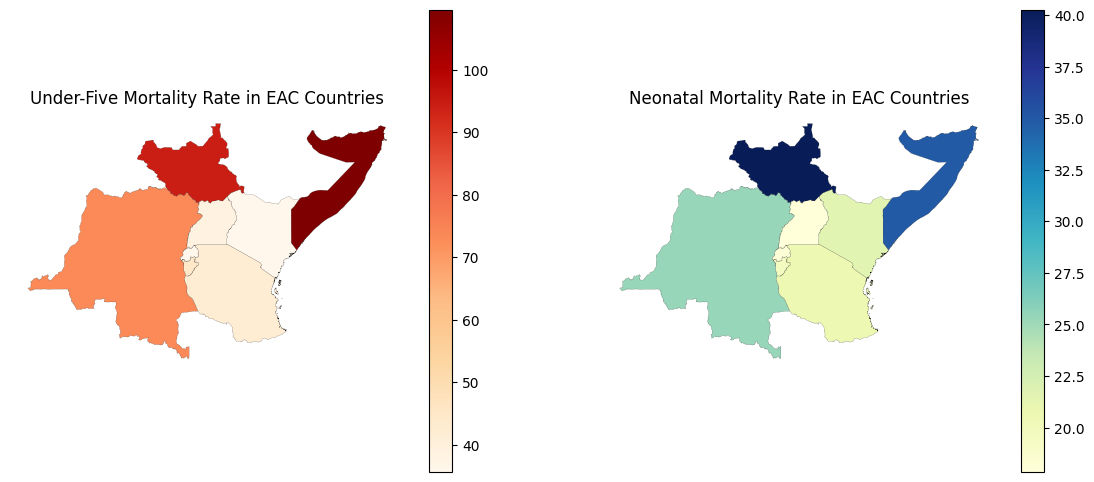

In [25]:
# Create a subplot with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Under-Five Mortality Rate
gdf_merged.plot(column='Under-five mortality rate', cmap='OrRd', legend=True, ax=ax[0], edgecolor='black', linewidth=0.1)
ax[0].set_title('Under-Five Mortality Rate in EAC Countries')
ax[0].axis('off')

# Plot for Neonatal Mortality Rate
gdf_merged.plot(column='Neonatal mortality rate', cmap='YlGnBu', legend=True, ax=ax[1], edgecolor='black', linewidth=0.1)
ax[1].set_title('Neonatal Mortality Rate in EAC Countries')
ax[1].axis('off')

# Display the plots
plt.show()


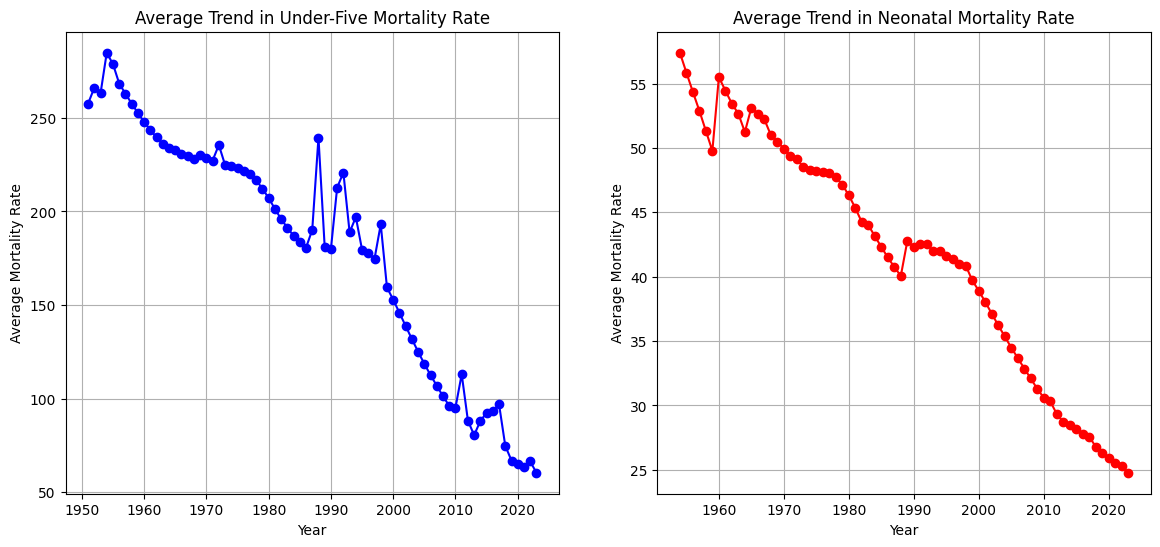

In [19]:
un_df['Reference Date'] = pd.to_datetime(un_df['Reference Date'], format='%Y')
filtered = un_df[un_df['Indicator'].isin(['Neonatal mortality rate', 'Under-five mortality rate'])]

avg_trends = filtered.groupby([filtered['Reference Date'].dt.year, 'Indicator']).mean(numeric_only=True).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

under_five = avg_trends[avg_trends['Indicator'] == 'Under-five mortality rate']
ax[0].plot(under_five['Reference Date'], under_five['Observation Value'], marker='o', color='blue')
ax[0].set_title('Average Trend in Under-Five Mortality Rate')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Average Mortality Rate')
ax[0].grid(True)

neonatal = avg_trends[avg_trends['Indicator'] == 'Neonatal mortality rate']
ax[1].plot(neonatal['Reference Date'], neonatal['Observation Value'], marker='o', color='red')
ax[1].set_title('Average Trend in Neonatal Mortality Rate')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Average Mortality Rate')
ax[1].grid(True)

plt.show()